# 3D pipeline: zero-shot FM rotation search
This notebook evaluates a 2D-trained rotation FM on the Ganis-Kievit 3D stimuli
(preprocessed in `data/train_pairs.npy` and `data/test_balanced.npy`).

We treat the FM as a rotation operator and perform a deterministic angle search.
No retraining. Metrics are computed on the balanced test set.


In [1]:
%cd /Users/masha/Documents/visual-reasoning

import os
import math
import random
from typing import List, Tuple, Dict, Any

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import timm

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

from sklearn.metrics import roc_auc_score, accuracy_score
import matplotlib.pyplot as plt


/Users/masha/Documents/visual-reasoning


/Users/masha/Documents/visual-reasoning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_PATH = "models/rotator_l1_500e_10k.pth"
FM_STEPS = 10
ANGLE_STEP = 10  # set to 5 for denser search
ANGLES = np.arange(0, 360, ANGLE_STEP, dtype=np.float32)

MAX_TEST = None   # set to int for quick debug
MAX_TRAIN = None  # set to int for quick debug


Device: cpu


In [3]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.net(x)

class FastRotator(nn.Module):
    def __init__(self, backbone_dim=384, flow_dim=64):
        super().__init__()
        self.time_mlp = nn.Sequential(nn.Linear(1, flow_dim * 4), nn.GELU(), nn.Linear(flow_dim * 4, flow_dim * 4))
        self.angle_mlp = nn.Sequential(nn.Linear(1, flow_dim * 4), nn.GELU(), nn.Linear(flow_dim * 4, flow_dim * 4))
        self.cond_proj = nn.Linear(backbone_dim, flow_dim * 4)

        self.inc = DoubleConv(1, flow_dim)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(flow_dim, flow_dim * 2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(flow_dim * 2, flow_dim * 4))

        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv1 = DoubleConv(flow_dim * 6, flow_dim * 2)
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv2 = DoubleConv(flow_dim * 3, flow_dim)

        self.outc = nn.Conv2d(flow_dim, 1, kernel_size=1)

    def forward(self, x_t, t, dino_emb, target_angle_deg):
        t_emb = self.time_mlp(t)
        d_emb = self.cond_proj(dino_emb)
        a_emb = self.angle_mlp(target_angle_deg / 360.0)
        global_cond = (t_emb + d_emb + a_emb).unsqueeze(-1).unsqueeze(-1)

        x1 = self.inc(x_t)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x3 = x3 + global_cond

        x = self.conv1(torch.cat([self.up1(x3), x2], dim=1))
        x = self.conv2(torch.cat([self.up2(x), x1], dim=1))
        return self.outc(x)


In [4]:
fm_model = FastRotator().to(device)
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(MODEL_PATH)
fm_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
fm_model.eval()
for p in fm_model.parameters():
    p.requires_grad = False

# DINOv3 backbone for conditioning
# We use forward_features to get the CLS token.
dino = timm.create_model("vit_small_patch16_dinov3", pretrained=True).to(device).eval()
for p in dino.parameters():
    p.requires_grad = False

@torch.no_grad()
def get_dino_embedding(img_64_tensor: torch.Tensor, dino_model: nn.Module = None) -> torch.Tensor:
    # img_64_tensor: (B, 1, 64, 64) in [-1, 1]
    if dino_model is None:
        dino_model = dino
    img = (img_64_tensor * 0.5) + 0.5
    img = F.interpolate(img, size=(224, 224), mode='bilinear', align_corners=False)
    img = img.repeat(1, 3, 1, 1)
    norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    img = norm(img)
    emb = dino_model.forward_features(img)[:, 0, :]
    return emb

@torch.no_grad()
def apply_rotation_fm(model, base_img, base_emb, angle_deg, steps=10):
    # base_img: (B, 1, 64, 64) in [-1, 1]
    model.eval()
    dt = 1.0 / steps
    curr = base_img.clone()
    B = base_img.shape[0]

    if torch.is_tensor(angle_deg):
        target_ang = angle_deg.to(base_img.device).float()
        if target_ang.dim() == 1:
            target_ang = target_ang.unsqueeze(1)
    else:
        target_ang = torch.full((B, 1), float(angle_deg), device=base_img.device, dtype=base_img.dtype)

    for i in range(steps):
        t = torch.full((B, 1), i / steps, device=base_img.device, dtype=base_img.dtype)
        v1 = model(curr, t, base_emb, target_ang)
        mid = curr + v1 * dt
        t2 = torch.full((B, 1), (i + 1) / steps, device=base_img.device, dtype=base_img.dtype)
        v2 = model(mid, t2, base_emb, target_ang)
        curr = curr + 0.5 * (v1 + v2) * dt
    curr = torch.nan_to_num(curr, nan=0.0, posinf=1.0, neginf=-1.0)
    curr = curr.clamp(-1.0, 1.0)
    return curr

@torch.no_grad()
def to_display(img: torch.Tensor) -> np.ndarray:
    # img: (B, 1, H, W) in [-1, 1] or (1, H, W)
    if img.dim() == 4:
        img = img[0]
    img = img.clamp(-1.0, 1.0)
    img = (img + 1.0) * 0.5
    return img[0].detach().cpu().numpy()


In [5]:
train_raw = np.load("data/train_pairs.npy", allow_pickle=True)
test_raw = np.load("data/test_balanced.npy", allow_pickle=True)

print("Train size:", len(train_raw))
print("Test size:", len(test_raw))
print("Example keys:", list(train_raw[0].keys()))

@torch.no_grad()
def sample_to_tensors(sample: Dict[str, Any], device=device) -> Tuple[torch.Tensor, torch.Tensor]:
    x0 = torch.tensor(sample["x0"]).float()  # (1, H, W) in [-1, 1]
    x1 = torch.tensor(sample["x1"]).float()
    if x0.dim() == 3:
        x0 = x0.unsqueeze(0)
    if x1.dim() == 3:
        x1 = x1.unsqueeze(0)
    return x0.to(device), x1.to(device)


Train size: 153
Test size: 78
Example keys: ['x0', 'x1', 'angle', 'name', 'label']


In [6]:
@torch.no_grad()
def min_error_over_angles(
    base: torch.Tensor,
    target: torch.Tensor,
    angles: np.ndarray,
    steps: int = 10,
    return_image: bool = False,
):
    base_emb = get_dino_embedding(base)
    best_err = float("inf")
    best_angle = None
    best_rot = None

    for ang in angles:
        rot = apply_rotation_fm(fm_model, base, base_emb, ang, steps=steps)
        err = torch.mean((rot - target) ** 2).item()
        if err < best_err:
            best_err = err
            best_angle = float(ang)
            if return_image:
                best_rot = rot.detach().clone()

    return best_err, best_angle, best_rot

@torch.no_grad()
def evaluate_pair(sample: Dict[str, Any], angles: np.ndarray, steps: int = 10) -> Dict[str, Any]:
    base, target = sample_to_tensors(sample)

    err_orig, ang_orig, _ = min_error_over_angles(base, target, angles, steps)

    base_flip = torch.flip(base, dims=[3])
    err_flip, ang_flip, _ = min_error_over_angles(base_flip, target, angles, steps)

    label_same = (sample.get("label") == "same")
    pred_same = err_orig <= err_flip
    score = err_flip - err_orig  # positive means more likely same

    return {
        "err_orig": err_orig,
        "err_flip": err_flip,
        "best_angle": ang_orig,
        "best_angle_flip": ang_flip,
        "label_same": label_same,
        "pred_same": pred_same,
        "score": score,
        "name": sample.get("name"),
        "angle": sample.get("angle"),
    }


In [7]:
results = []
raw_iter = test_raw[:MAX_TEST] if MAX_TEST is not None else test_raw

for sample in tqdm(raw_iter, total=len(raw_iter)):
    results.append(evaluate_pair(sample, ANGLES, steps=FM_STEPS))

labels = np.array([1 if r["label_same"] else 0 for r in results], dtype=np.int32)
preds = np.array([1 if r["pred_same"] else 0 for r in results], dtype=np.int32)
scores = np.array([r["score"] for r in results], dtype=np.float32)

acc = accuracy_score(labels, preds)
auc = roc_auc_score(labels, scores)

print("FM rotation search results")
print("  Accuracy (mirror-vs-rotation rule):", f"{acc:.4f}")
print("  AUC (score = err_flip - err_orig):", f"{auc:.4f}")

# Also report AUC using only rotation error (lower is more same)
err_orig = np.array([r["err_orig"] for r in results], dtype=np.float32)
auc_rot = roc_auc_score(labels, -err_orig)
print("  AUC (score = -min_rotation_error):", f"{auc_rot:.4f}")


100%|██████████| 78/78 [14:19<00:00, 11.01s/it]

FM rotation search results
  Accuracy (mirror-vs-rotation rule): 0.6538
  AUC (score = err_flip - err_orig): 0.6778
  AUC (score = -min_rotation_error): 0.6502


In [8]:
# Optional: threshold rule using train SAME pairs only
train_iter = train_raw[:MAX_TRAIN] if MAX_TRAIN is not None else train_raw
train_errs = []

for sample in tqdm(train_iter, total=len(train_iter)):
    base, target = sample_to_tensors(sample)
    err, _, _ = min_error_over_angles(base, target, ANGLES, steps=FM_STEPS)
    train_errs.append(err)

train_errs = np.array(train_errs)
threshold = np.percentile(train_errs, 95)
print("Threshold from train SAME (95th percentile):", threshold)

preds_thresh = (err_orig <= threshold).astype(np.int32)
acc_thresh = accuracy_score(labels, preds_thresh)
print("Accuracy (threshold rule):", f"{acc_thresh:.4f}")


100%|██████████| 153/153 [15:40<00:00,  6.15s/it]

Threshold from train SAME (95th percentile): 1.0074413061141967
Accuracy (threshold rule): 0.4872


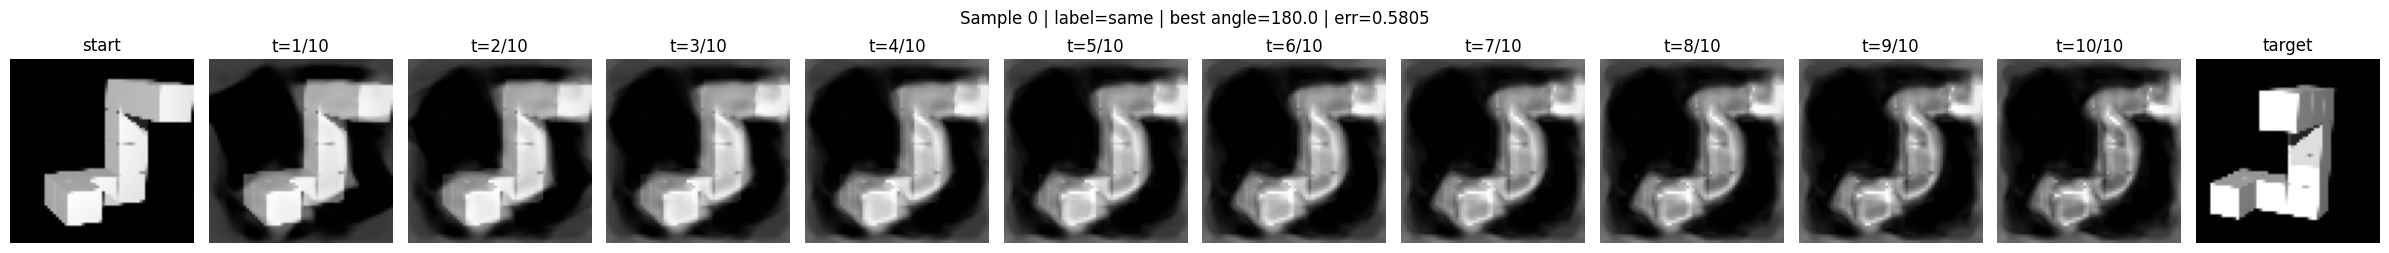

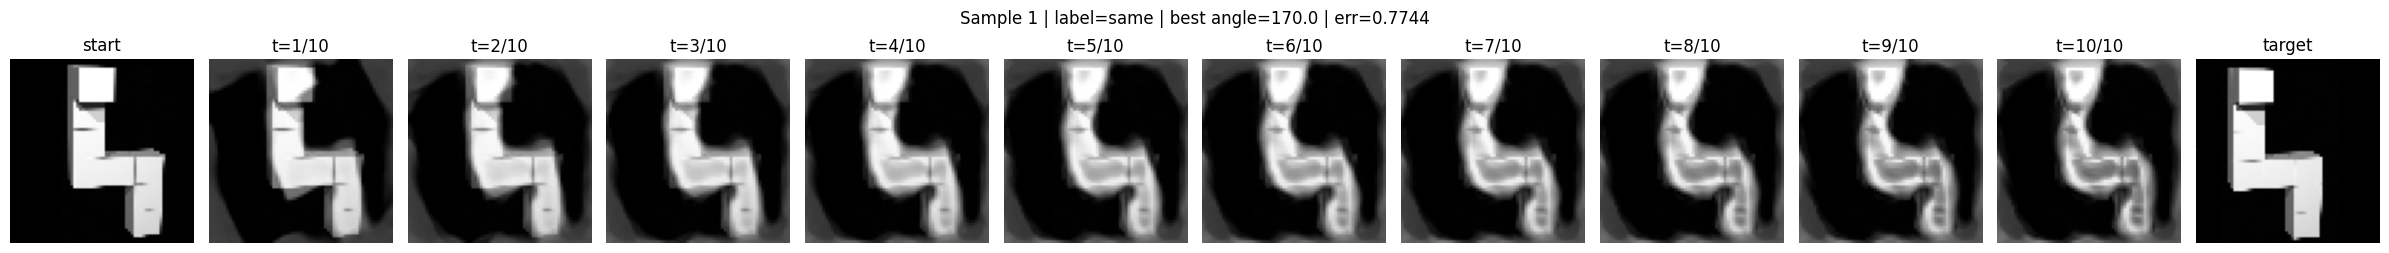

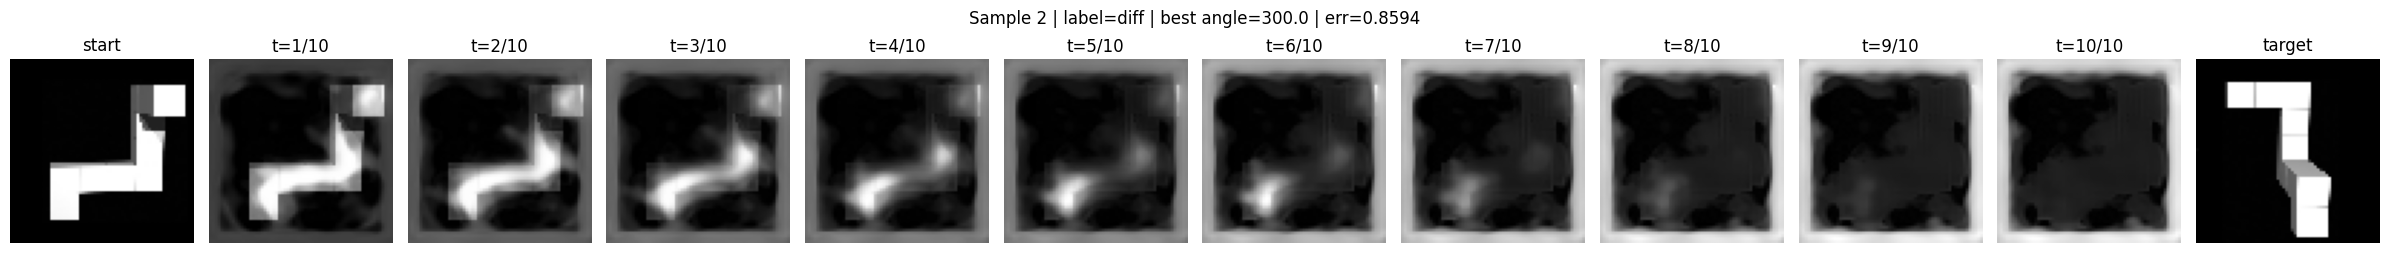

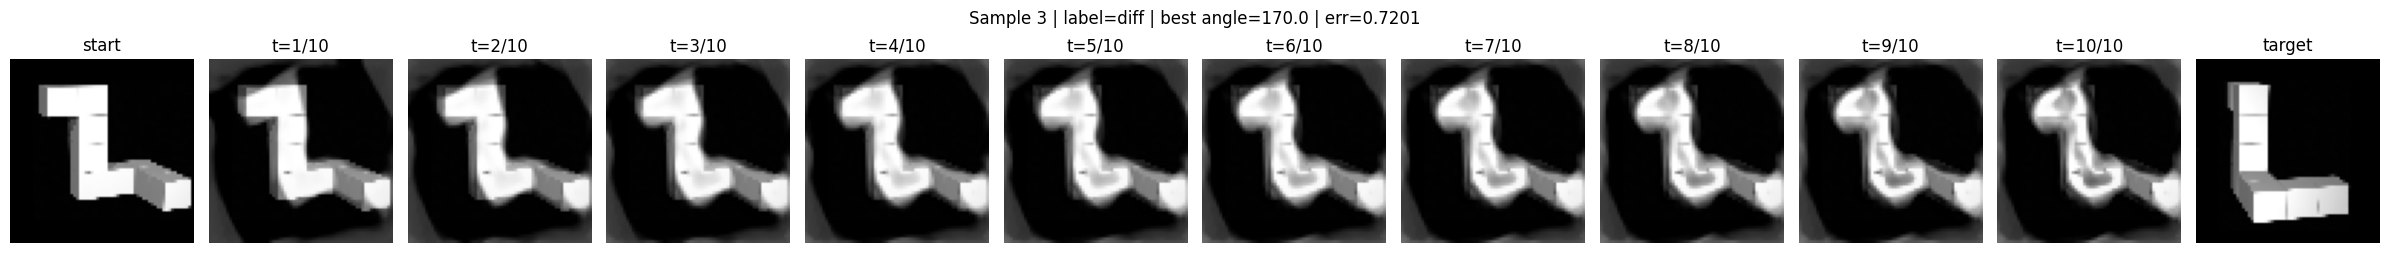

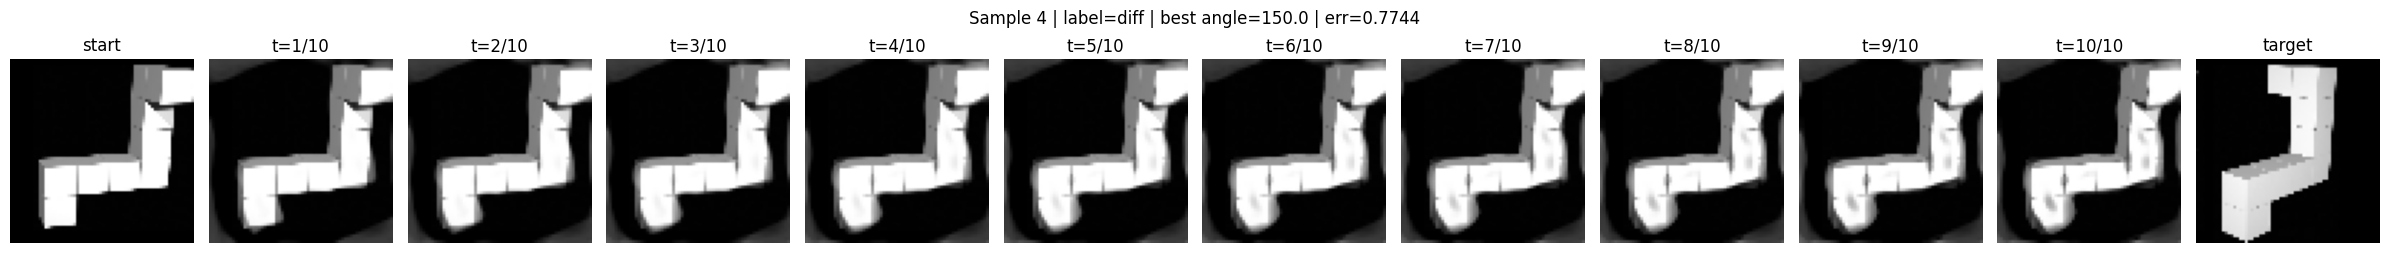

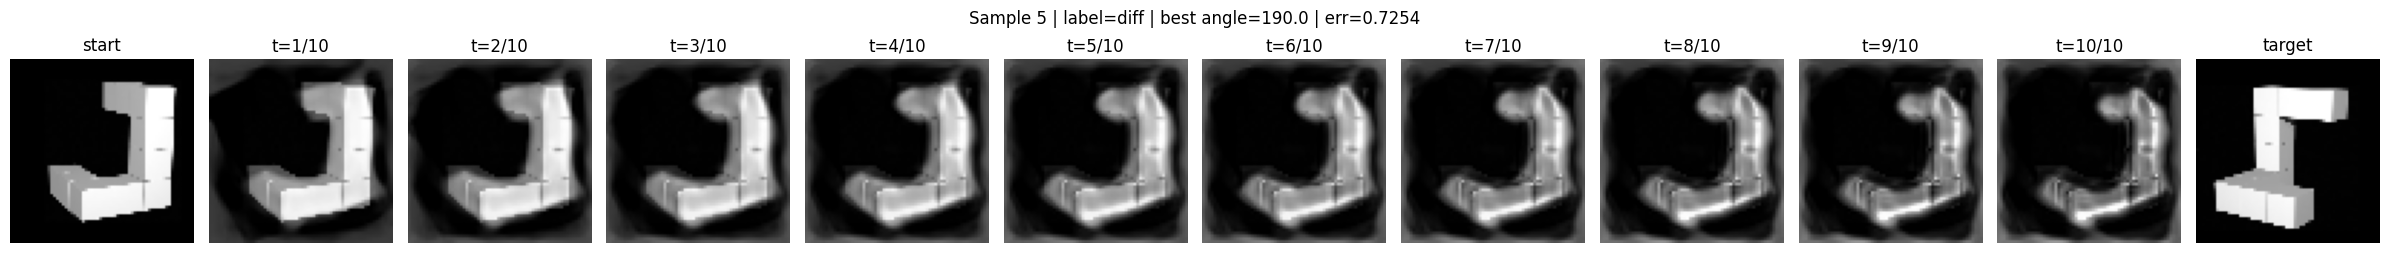

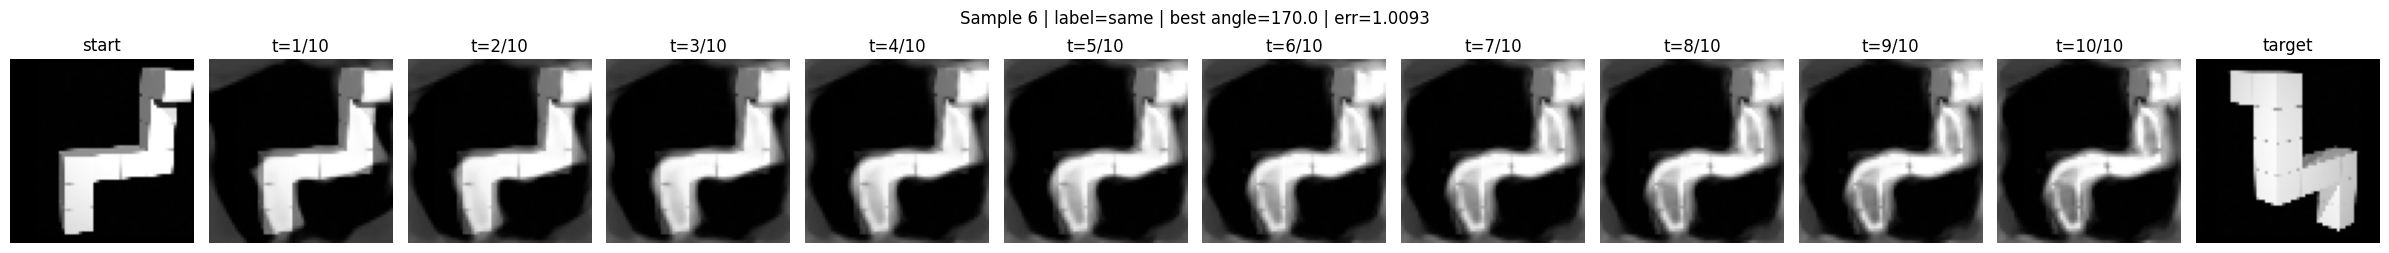

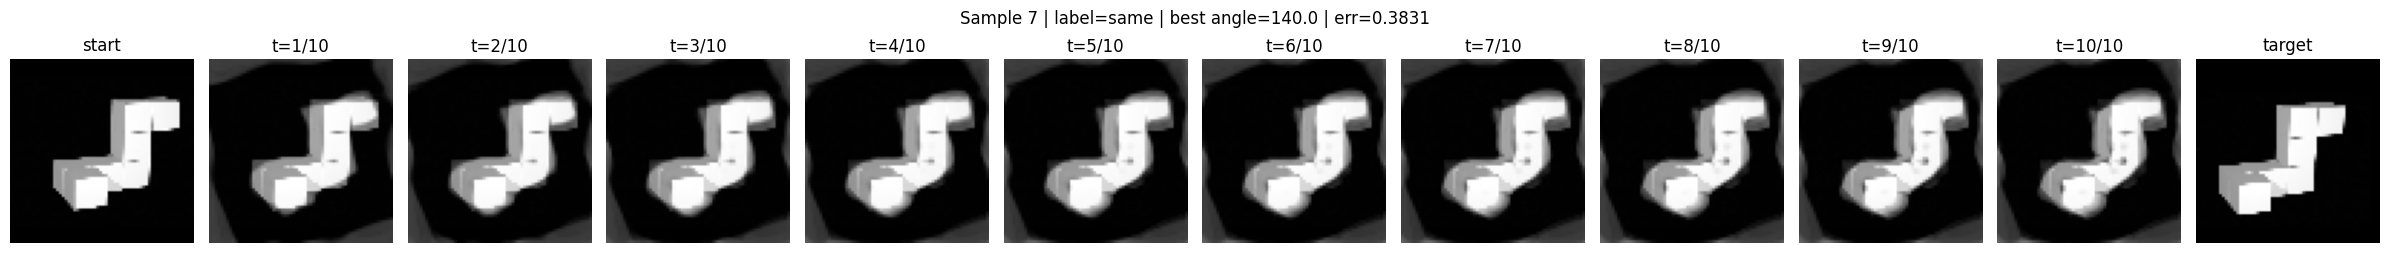

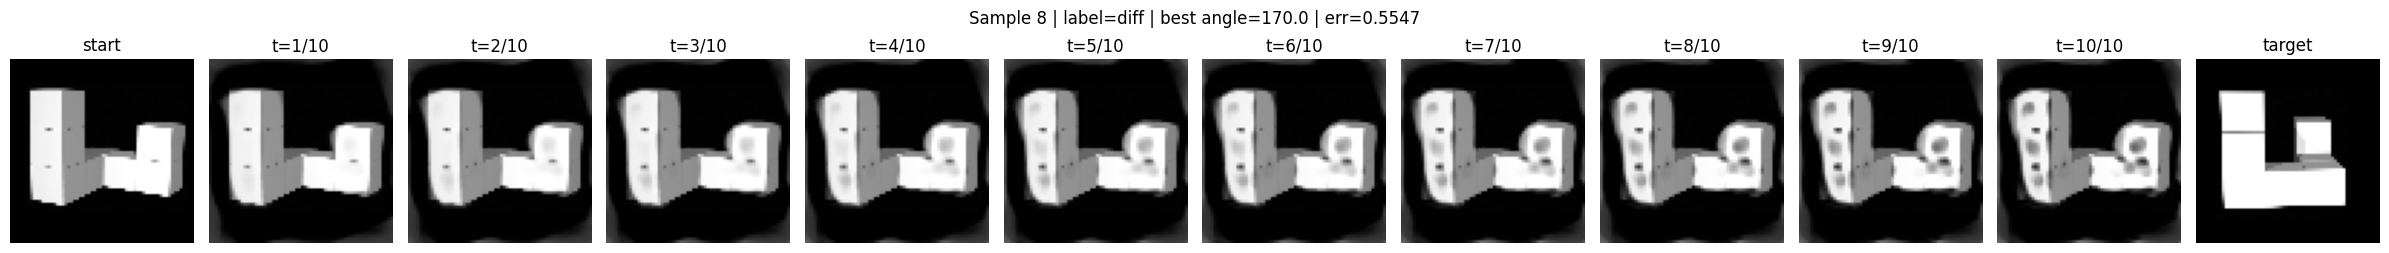

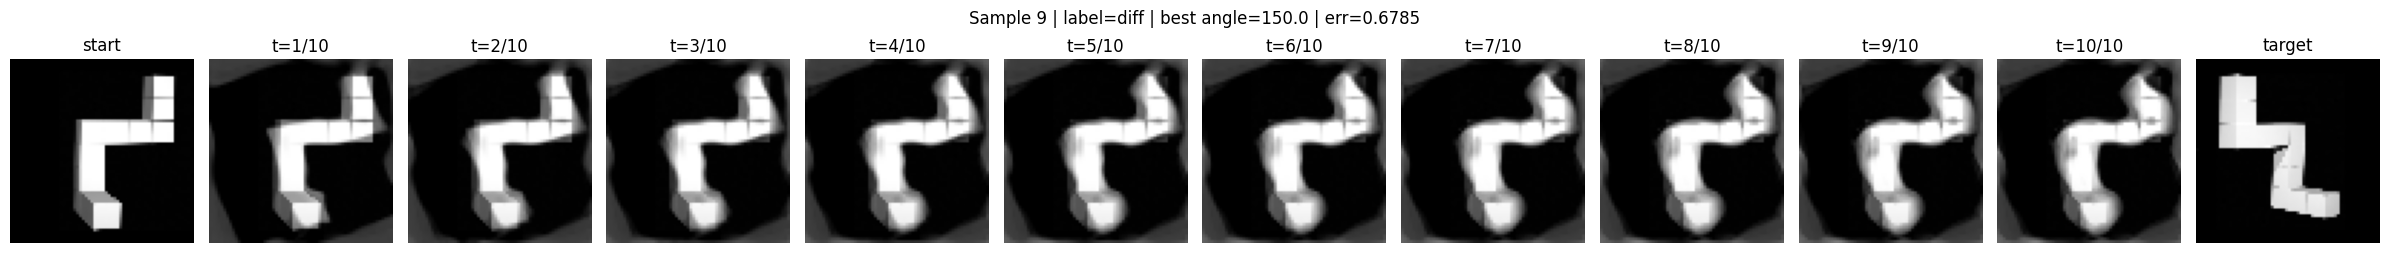

In [13]:
# Qualitative examples with intermediate FM steps
@torch.no_grad()
def apply_rotation_fm_with_traj(model, base_img, base_emb, angle_deg, steps=10):
    # base_img: (B, 1, 64, 64) in [-1, 1]
    model.eval()
    dt = 1.0 / steps
    curr = base_img.clone()
    B = base_img.shape[0]

    if torch.is_tensor(angle_deg):
        target_ang = angle_deg.to(base_img.device).float()
        if target_ang.dim() == 1:
            target_ang = target_ang.unsqueeze(1)
    else:
        target_ang = torch.full((B, 1), float(angle_deg), device=base_img.device, dtype=base_img.dtype)

    frames = [curr.detach().clone()]
    for i in range(steps):
        t = torch.full((B, 1), i / steps, device=base_img.device, dtype=base_img.dtype)
        v1 = model(curr, t, base_emb, target_ang)
        mid = curr + v1 * dt
        t2 = torch.full((B, 1), (i + 1) / steps, device=base_img.device, dtype=base_img.dtype)
        v2 = model(mid, t2, base_emb, target_ang)
        curr = curr + 0.5 * (v1 + v2) * dt
        curr = torch.nan_to_num(curr, nan=0.0, posinf=1.0, neginf=-1.0)
        curr = curr.clamp(-1.0, 1.0)
        frames.append(curr.detach().clone())
    return frames

# pick a few sample indices to visualize
sample_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

for idx in sample_indices:
    if idx >= len(test_raw):
        continue
    sample = test_raw[idx]
    base, target = sample_to_tensors(sample)

    # find best rotation angle for the original (non-flipped) case
    err_orig, ang_orig, _ = min_error_over_angles(base, target, ANGLES, steps=FM_STEPS, return_image=False)

    base_emb = get_dino_embedding(base)
    frames = apply_rotation_fm_with_traj(fm_model, base, base_emb, ang_orig, steps=FM_STEPS)

    n = len(frames) + 1  # +1 for target
    fig, axes = plt.subplots(1, n, figsize=(2.0 * n, 2.6))

    # start frame
    axes[0].imshow(to_display(frames[0]), cmap="gray")
    axes[0].set_title("start")
    axes[0].axis("off")

    # intermediate frames
    for i, fr in enumerate(frames[1:], start=1):
        axes[i].imshow(to_display(fr), cmap="gray")
        axes[i].set_title(f"t={i}/{FM_STEPS}")
        axes[i].axis("off")

    # target image
    axes[-1].imshow(to_display(target), cmap="gray")
    axes[-1].set_title("target")
    axes[-1].axis("off")

    plt.suptitle(f"Sample {idx} | label={sample.get('label')} | best angle={ang_orig} | err={err_orig:.4f}")
    plt.tight_layout()
    plt.show()

In [14]:
# Save GIFs for a few samples
import os
import imageio.v2 as imageio

GIF_OUT_DIR = "gifs/ganis_kievit"
os.makedirs(GIF_OUT_DIR, exist_ok=True)

sample_indices = [0, 1, 2]

@torch.no_grad()
def frames_to_uint8(frames: list) -> list:
    imgs = []
    for fr in frames:
        img = to_display(fr)  # (H, W) in [0,1]
        img = (img * 255).astype(np.uint8)
        imgs.append(img)
    return imgs

for idx in sample_indices:
    if idx >= len(test_raw):
        continue
    sample = test_raw[idx]
    base, target = sample_to_tensors(sample)

    # best angle for original
    err_orig, ang_orig, _ = min_error_over_angles(base, target, ANGLES, steps=FM_STEPS, return_image=False)
    base_emb = get_dino_embedding(base)

    # trajectory frames
    frames = apply_rotation_fm_with_traj(fm_model, base, base_emb, ang_orig, steps=FM_STEPS)
    frames.append(target.detach().clone())

    imgs = frames_to_uint8(frames)
    out_path = os.path.join(GIF_OUT_DIR, f"sample_{idx}_label_{sample.get('label')}_angle_{int(ang_orig)}.gif")
    imageio.mimsave(out_path, imgs, fps=5)
    print("Saved", out_path)


Saved gifs/ganis_kievit/sample_0_label_same_angle_180.gif
Saved gifs/ganis_kievit/sample_1_label_same_angle_170.gif
Saved gifs/ganis_kievit/sample_2_label_diff_angle_300.gif
